In [1]:
import numpy as np
data = np.load('SOAP_data_with_H_ads_energy.npz')
descs = data['descs']
e_ads_per_h = data['e_ads_per_h']

In [3]:
print(descs.shape)
print(e_ads_per_h.shape)

(545, 780)
(545,)


In [4]:
X = descs
y = e_ads_per_h

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

In [6]:
print(np.max(X), np.min(X))

1387.9950982850587 -292.1803865769172


In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.svm import SVR
# from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
# from xgboost import XGBRegressor

In [8]:
def screen_regression_models_on_train_set_using_cv(model_list:dict, X_train, y_train, compare_scaled=True):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
    from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, cross_validate
    model_list = list(model_dict.keys())
    mae_scores = []
    mse_scores = []
    rmse_scores =[]
    r2_scores_train = []
    r2_scores_test = []
    scorer = {'MAE': make_scorer(mean_absolute_error), 'MSE': make_scorer(mean_squared_error), 'RMSE': 'neg_root_mean_squared_error',
             'R2': make_scorer(r2_score)}
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    for key, model in model_dict.items():
        print(key)
        # Generate cross-validated predictions
        cv_scores = cross_validate(model, X_train, y_train, cv=kf, scoring=scorer, return_train_score=True)
        
        r2_scores_train.append(float(np.mean(cv_scores['train_R2'])))
        r2_scores_test.append(float(np.mean(cv_scores['test_R2'])))
        
    if compare_scaled:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        r2_scores_scaled_train = []
        r2_scores_scaled_test = []
        for key, model in model_dict.items():
            print(key)
            
            # Generate cross-validated predictions
            cv_scores = cross_validate(model, X_train_scaled,
                                       y_train, cv=kf, scoring=scorer, return_train_score=True)

            r2_scores_scaled_train.append(float(np.mean(cv_scores['train_R2'])))
            r2_scores_scaled_test.append(float(np.mean(cv_scores['test_R2'])))

    model_performance = {'Model': model_list, 'R2 train': r2_scores_train, 
                         'R2 train scaled': r2_scores_scaled_train, 
                         'R2 test': r2_scores_test, 'R2 test scaled': r2_scores_scaled_test}
    return model_performance

In [9]:
lr = LinearRegression()
kernelreg = KernelRidge()
model_dict = {'Linear_Regression': lr, 'Kernel Ridge': kernelreg}

In [10]:
model_performance = screen_regression_models_on_train_set_using_cv(model_dict, X_train, y_train)

Linear_Regression
Kernel Ridge
Linear_Regression
Kernel Ridge


In [11]:
import pandas as pd
model_performance = pd.DataFrame(model_performance).sort_values(by='R2 train', ascending=False)
print(model_performance)

               Model      R2 train  R2 train scaled       R2 test  \
1       Kernel Ridge  1.934073e-10      -262.285191 -8.321393e-02   
0  Linear_Regression -4.539931e+22         0.000000 -4.367802e+22   

   R2 test scaled  
1     -318.407008  
0       -0.083214  


In [12]:
from sklearn.model_selection import GridSearchCV
best_parameters = {}
print(f'training started')
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# print(np.max(X_test_scaled), np.min(X_test_scaled))
param_grid = {'alpha': [0.5, 1, 2], 'degree': [1, 2, 3, 4]}
grid_search = GridSearchCV(KernelRidge(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
# best_parameters = grid_search.best_params_
print(f"Best parameters: ", grid_search.best_params_)

training started
Best parameters:  {'alpha': 2, 'degree': 1}


In [18]:
model = KernelRidge(alpha=2, degree=1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, cross_validate
scorer = {'MAE': make_scorer(mean_absolute_error), 'MSE': make_scorer(mean_squared_error), 'RMSE': 'neg_root_mean_squared_error',
             'R2': make_scorer(r2_score)}
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_validate(model, X_train, y_train, cv=kf, scoring=scorer, return_train_score=True)
        
print(float(np.mean(cv_scores['train_MSE'])))
print(float(np.mean(cv_scores['test_MSE'])))

0.05876612380545906
0.05976654845629992


Let us test a neural network (from tensorflow)

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

In [21]:
def generate_net(X_train, y_train):
    model = Sequential([Input(shape=(X_train.shape[1],))])

    model.add(Dense(30, activation='relu'))

    # Hidden layer
    model.add(Dense(20, activation='relu'))
    model.add(Dense(15, activation='relu'))
    model.add(Dense(10, activation='relu'))

    # Output layer
    model.add(Dense(1, activation='linear'))
    return model

def generate_net_less_complex(X_train, y_train):
    model = Sequential([Input(shape=(X_train.shape[1],))])

    model.add(Dense(25, activation='relu'))

    # Hidden layer
    model.add(Dense(15, activation='relu'))
    model.add(Dense(10, activation='relu'))

    # Output layer
    model.add(Dense(1, activation='linear'))
    return model

In [23]:
model = generate_net(X_train,y_train)
model.compile(optimizer='adam',
              loss='mae',
              metrics=['mae'])
history = model.fit(X_train, y_train, 
                    validation_split=0.2, 
                    epochs=200, 
                    batch_size=8, 
                    verbose=1)
# model.save('models/NN_mae.keras')

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 8.2135 - mae: 8.2135 - val_loss: 0.3152 - val_mae: 0.3152
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3003 - mae: 0.3003 - val_loss: 0.1792 - val_mae: 0.1792
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4880 - mae: 0.4880 - val_loss: 0.2300 - val_mae: 0.2300
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3639 - mae: 0.3639 - val_loss: 0.3060 - val_mae: 0.3060
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3490 - mae: 0.3490 - val_loss: 0.5018 - val_mae: 0.5018
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3246 - mae: 0.3246 - val_loss: 0.4434 - val_mae: 0.4434
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6032 - mae: 0.6032 - val_loss: 0.6369 - val_mae: 0.6369
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5242 - mae: 0.5242 - val_loss: 0.2671 - val_mae: 0.2671
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.25

Epoch 55/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2331 - mae: 0.2331 - val_loss: 0.1834 - val_mae: 0.1834
Epoch 56/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1962 - mae: 0.1962 - val_loss: 0.2611 - val_mae: 0.2611
Epoch 57/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2158 - mae: 0.2158 - val_loss: 0.1949 - val_mae: 0.1949
Epoch 58/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1873 - mae: 0.1873 - val_loss: 0.1783 - val_mae: 0.1783
Epoch 59/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2385 - mae: 0.2385 - val_loss: 0.2473 - val_mae: 0.2473
Epoch 60/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2159 - mae: 0.2159 - val_loss: 0.3506 - val_mae: 0.3506
Epoch 61/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2154 - mae: 0.2154 - val_loss: 0.1843 - val_mae: 0.1843
Epoch 62/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2192 - mae: 0.2192 - val_loss: 0.1811 - val_mae: 0.1811
Epoch 63/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - lo

Epoch 109/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1819 - mae: 0.1819 - val_loss: 0.1946 - val_mae: 0.1946
Epoch 110/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1929 - mae: 0.1929 - val_loss: 0.1864 - val_mae: 0.1864
Epoch 111/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2147 - mae: 0.2147 - val_loss: 0.3014 - val_mae: 0.3014
Epoch 112/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2200 - mae: 0.2200 - val_loss: 0.2711 - val_mae: 0.2711
Epoch 113/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2730 - mae: 0.2730 - val_loss: 0.1984 - val_mae: 0.1984
Epoch 114/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2571 - mae: 0.2571 - val_loss: 0.1907 - val_mae: 0.1907
Epoch 115/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2030 - mae: 0.2030 - val_loss: 0.1980 - val_mae: 0.1980
Epoch 116/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2191 - mae: 0.2191 - val_loss: 0.1813 - val_mae: 0.1813
Epoch 117/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1987 - mae: 0.1987 - val_loss: 0.1794 - val_mae: 0.1794
Epoch 163/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1801 - mae: 0.1801 - val_loss: 0.1891 - val_mae: 0.1891
Epoch 164/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2133 - mae: 0.2133 - val_loss: 0.2165 - val_mae: 0.2165
Epoch 165/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2440 - mae: 0.2440 - val_loss: 0.1786 - val_mae: 0.1786
Epoch 166/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1806 - mae: 0.1806 - val_loss: 0.1894 - val_mae: 0.1894
Epoch 167/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1965 - mae: 0.1965 - val_loss: 0.1853 - val_mae: 0.1853
Epoch 168/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2311 - mae: 0.2311 - val_loss: 0.1795 - val_mae: 0.1795
Epoch 169/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1959 - mae: 0.1959 - val_loss: 0.2059 - val_mae: 0.2059
Epoch 170/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 

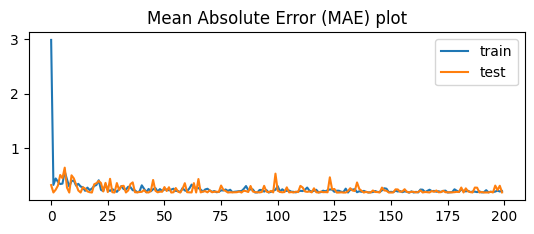

In [25]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.subplot(212)
plt.title('Mean Absolute Error (MAE) plot')
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='test')
plt.legend()
plt.show()
fig.clear()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
(109,)


C:\Users\akash\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\akash\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


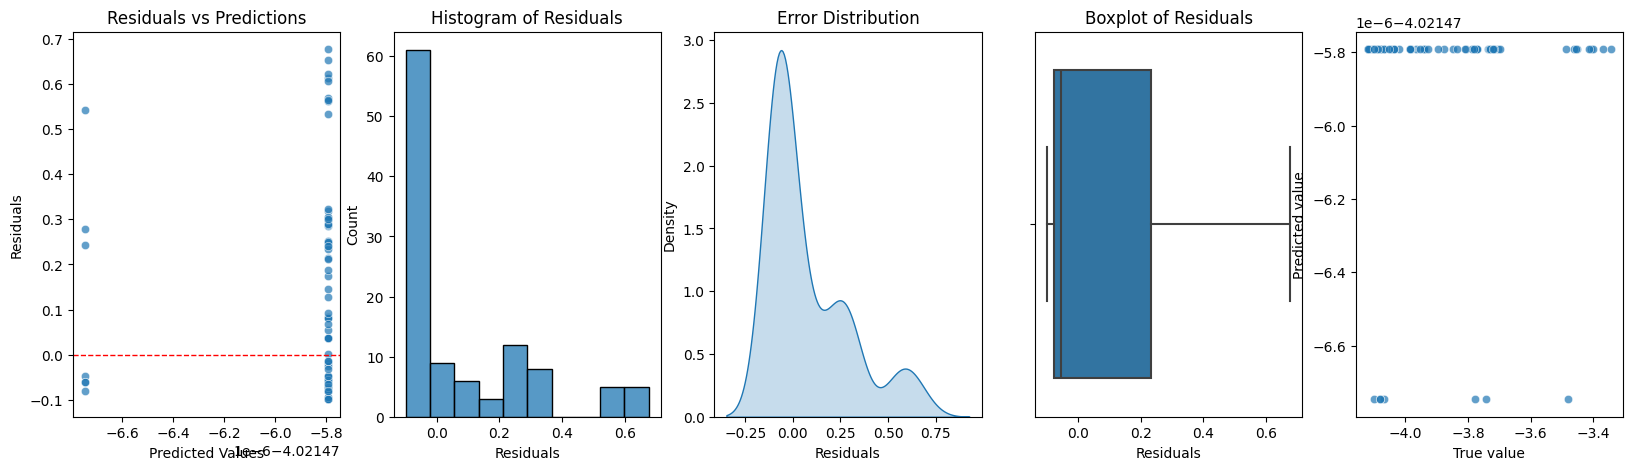

In [45]:
import seaborn as sns
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()
print(y_pred.shape)
residual = (np.array(y_test)-y_pred).flatten()
fig, ax = plt.subplots(1,5,figsize=(20,5))
sns.scatterplot(x=np.array(y_test), y=y_pred, alpha=0.7, ax=ax[4])
sns.scatterplot(x=y_pred, y=residual, alpha=0.7, ax=ax[0])
sns.histplot(residual, bins=10, ax=ax[1])
sns.kdeplot(residual, fill=True, ax=ax[2])
sns.boxplot(x=residual, ax=ax[3])
ax[0].axhline(0, color='red', linestyle='--', linewidth=1)
ax[0].set_title(f"Residuals vs Predictions")
ax[0].set_xlabel("Predicted Values")
ax[0].set_ylabel("Residuals")
ax[1].set_title(f"Histogram of Residuals")
ax[2].set_title(f"Error Distribution")
ax[3].set_title(f"Boxplot of Residuals")
ax[1].set_xlabel("Residuals")
ax[2].set_xlabel("Residuals")
ax[3].set_xlabel("Residuals")
ax[4].set_xlabel("True value")
ax[4].set_ylabel("Predicted value")
#     plt.savefig(f'Performance of XGB on test set for {col}.png')
plt.show()
fig.clear()